<a href="https://colab.research.google.com/github/sadikiabubakari698-crypto/data-analyst-portfolio/blob/main/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/DataAnalysis/sales_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df.shape

(78, 9)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   OrderID    78 non-null     int64  
 1   OrderDate  78 non-null     object 
 2   Product    78 non-null     object 
 3   Category   78 non-null     object 
 4   Quantity   75 non-null     float64
 5   UnitPrice  76 non-null     float64
 6   Region     73 non-null     object 
 7   Customer   78 non-null     object 
 8   Sales      78 non-null     int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 5.6+ KB


In [4]:
df.drop_duplicates(inplace =True)
df.shape

(76, 9)

In [5]:
df.loc[df['Quantity'].isnull(), 'Quantity'] = df['Sales'] / df['UnitPrice']
df['Quantity'].isnull().sum()

np.int64(0)

In [6]:
df.loc[df['UnitPrice'].isnull(), 'UnitPrice'] = df['Sales'] / df['Quantity']
df['UnitPrice'].isnull().sum()

np.int64(0)

In [7]:
df.to_csv('/content/drive/MyDrive/DataAnalysis/sales_cleaned.csv', index=False)
print("Data imehifadhiwa!")

Data imehifadhiwa!


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76 entries, 0 to 76
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   OrderID    76 non-null     int64  
 1   OrderDate  76 non-null     object 
 2   Product    76 non-null     object 
 3   Category   76 non-null     object 
 4   Quantity   76 non-null     float64
 5   UnitPrice  76 non-null     float64
 6   Region     71 non-null     object 
 7   Customer   76 non-null     object 
 8   Sales      76 non-null     int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 8.0+ KB


In [9]:
df["OrderDate"].head(10)
df["OrderDate"].dtype

dtype('O')

In [10]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['OrderDate'].dtype

dtype('<M8[ns]')

In [11]:
df['OrderDate'].head(10)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76 entries, 0 to 76
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   OrderID    76 non-null     int64         
 1   OrderDate  76 non-null     datetime64[ns]
 2   Product    76 non-null     object        
 3   Category   76 non-null     object        
 4   Quantity   76 non-null     float64       
 5   UnitPrice  76 non-null     float64       
 6   Region     71 non-null     object        
 7   Customer   76 non-null     object        
 8   Sales      76 non-null     int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 8.0+ KB


In [12]:
df.to_csv('/content/drive/MyDrive/DataAnalysis/sales_cleaned.csv', index=False)
print("Data imehifadhiwa!")

Data imehifadhiwa!


In [13]:
df['Sales'].sum()

np.int64(6567000)

In [14]:
df.shape[0]

76

In [15]:
df['Customer'].nunique()

24

In [16]:
df['Region'].nunique()
df['Region'].unique()

array(['Dar es Salaam', 'Dodoma', 'Zanzibar', 'Arusha', 'Mwanza', nan],
      dtype=object)

In [17]:
print("Products:", df['Product'].nunique())
print("Categories:", df['Category'].nunique())

Products: 20
Categories: 5


In [18]:
df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

,Sales
Product,
Wireless Earbuds,1750000
Women's Kitenge Dress,1600000
Bluetooth Speaker,405000
Denim Jeans,390000
Yoga Mat,336000
Perfume,288000
Bed Sheets,250000
Thermos Flask,220000
Power Bank,200000


In [19]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Electronics,2539000
Clothing,2125000
Home,816000
Beauty,561000
Sports,526000


In [20]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

,Sales
Region,
Dar es Salaam,2676000
Arusha,1460000
Mwanza,801000
Zanzibar,636000
Dodoma,598000


In [21]:
df.groupby('Customer')['Sales'].sum().sort_values(ascending=False).head(5)

,Sales
Customer,
CUST020,785000
CUST007,441000
CUST002,425000
CUST018,423000
CUST019,420000


In [22]:
df.groupby(df['OrderDate'].dt.month)['Sales'].sum()

,Sales
OrderDate,
1,746000
2,478000
3,447000
4,243000
5,379000
6,458000
7,428000
8,403000
9,585000


In [23]:
df.groupby(df['OrderDate'].dt.quarter)['Sales'].sum()

,Sales
OrderDate,
1,1671000
2,1080000
3,1416000
4,2400000


In [24]:
df.groupby([df['OrderDate'].dt.month, 'Product'])['Sales'].sum()

OrderDate  Product              
1          Cooking Pot Set          120000
           LED Lamp                  48000
           Phone Charger             48000
           Wireless Earbuds         210000
           Women's Kitenge Dress    320000
                                     ...  
12         Perfume                  160000
           Power Bank               100000
           Shea Butter Soap          25000
           Sunscreen                 56000
           Wireless Earbuds         210000
Name: Sales, Length: 64, dtype: int64

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

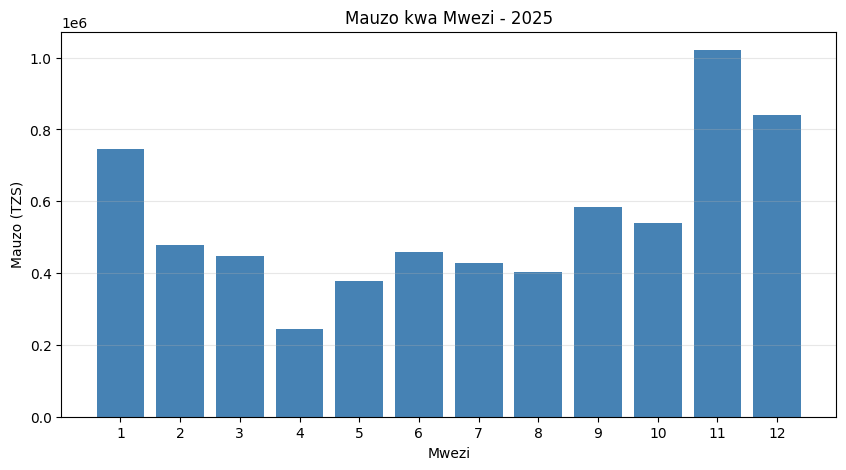

In [26]:
monthly = df.groupby(df['OrderDate'].dt.month)['Sales'].sum()

plt.figure(figsize=(10, 5))
plt.bar(monthly.index, monthly.values, color='steelblue')
plt.xlabel('Mwezi')
plt.ylabel('Mauzo (TZS)')
plt.title('Mauzo kwa Mwezi - 2025')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)
plt.show()

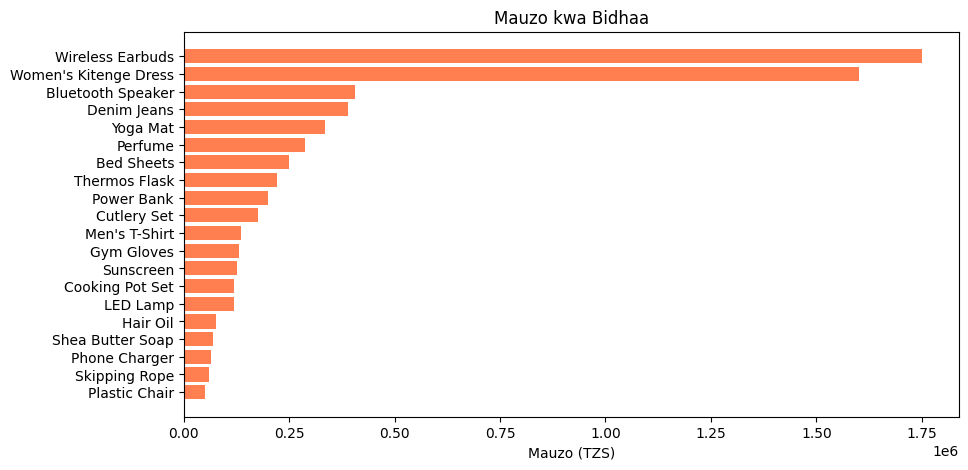

In [27]:
product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(product_sales.index, product_sales.values, color='coral')
plt.xlabel('Mauzo (TZS)')
plt.title('Mauzo kwa Bidhaa')
plt.gca().invert_yaxis()
plt.show()

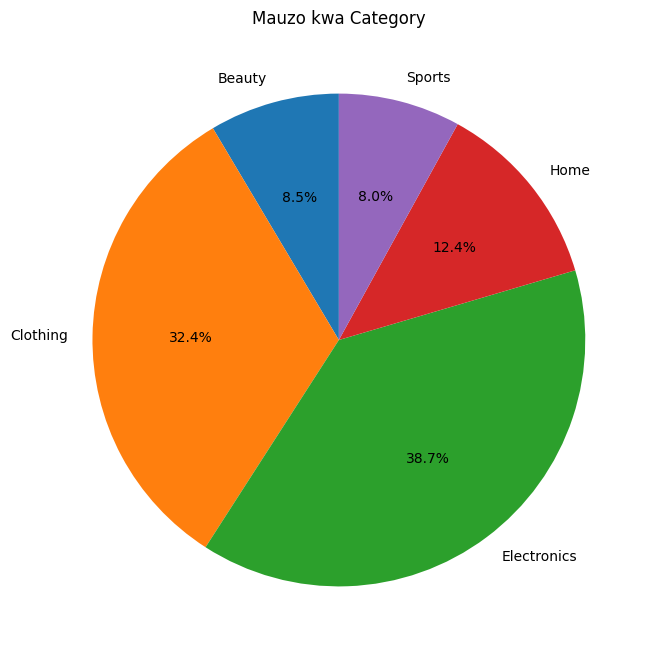

In [28]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8, 8))
plt.pie(category_sales.values, labels=category_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('Mauzo kwa Category')
plt.show()

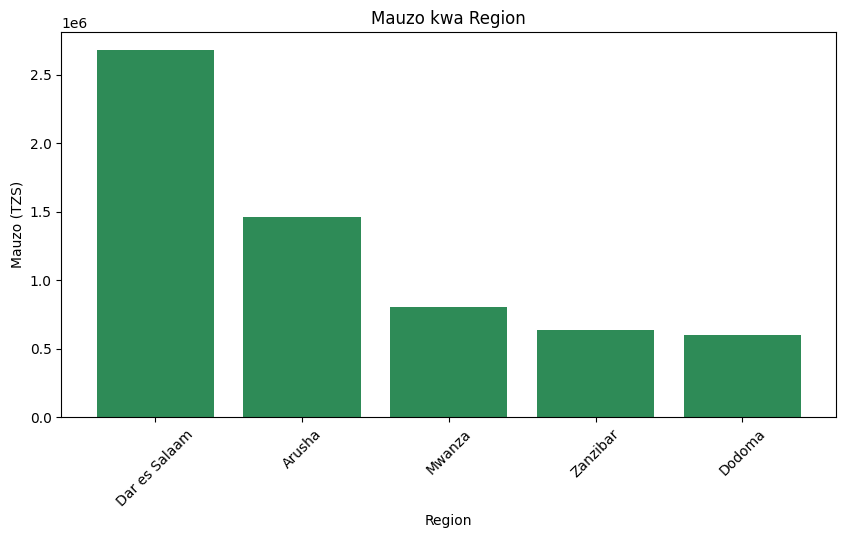

In [29]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(region_sales.index, region_sales.values, color='seagreen')
plt.xlabel('Region')
plt.ylabel('Mauzo (TZS)')
plt.title('Mauzo kwa Region')
plt.xticks(rotation=45)
plt.show()

In [30]:
top_customers = df.groupby('Customer')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers.to_string())

Customer
CUST020    785000
CUST007    441000
CUST002    425000
CUST018    423000
CUST019    420000
CUST001    400000
CUST005    382000
CUST025    363000
CUST024    338000
CUST008    322000


In [31]:
repeat_customers = df.groupby('Customer')['OrderID'].count().sort_values(ascending=False).head(10)
print(repeat_customers.to_string())

Customer
CUST001    6
CUST025    6
CUST018    6
CUST007    5
CUST020    4
CUST019    4
CUST008    4
CUST002    4
CUST024    3
CUST022    3


In [32]:
avg_order = df['Sales'].sum() / df['Customer'].nunique()
print(f"Wastani wa mauzo kwa mteja: TZS {avg_order:,.0f}")

Wastani wa mauzo kwa mteja: TZS 273,625


In [33]:
product_qty = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print(product_qty.to_string())

Product
Wireless Earbuds         50.0
Women's Kitenge Dress    40.0
Shea Butter Soap         14.0
Denim Jeans              13.0
Yoga Mat                 12.0
Hair Oil                 11.0
Thermos Flask            11.0
Bed Sheets               10.0
LED Lamp                 10.0
Skipping Rope            10.0
Gym Gloves               10.0
Bluetooth Speaker         9.0
Sunscreen                 9.0
Men's T-Shirt             9.0
Perfume                   9.0
Cutlery Set               8.0
Power Bank                8.0
Phone Charger             8.0
Plastic Chair             5.0
Cooking Pot Set           2.0


In [34]:
comparison = df.groupby('Product').agg({
    'Sales': 'sum',
    'Quantity': 'sum'
}).sort_values('Sales', ascending=False)
print(comparison.to_string())

                         Sales  Quantity
Product                                 
Wireless Earbuds       1750000      50.0
Women's Kitenge Dress  1600000      40.0
Bluetooth Speaker       405000       9.0
Denim Jeans             390000      13.0
Yoga Mat                336000      12.0
Perfume                 288000       9.0
Bed Sheets              250000      10.0
Thermos Flask           220000      11.0
Power Bank              200000       8.0
Cutlery Set             176000       8.0
Men's T-Shirt           135000       9.0
Gym Gloves              130000      10.0
Sunscreen               126000       9.0
Cooking Pot Set         120000       2.0
LED Lamp                120000      10.0
Hair Oil                 77000      11.0
Shea Butter Soap         70000      14.0
Phone Charger            64000       8.0
Skipping Rope            60000      10.0
Plastic Chair            50000       5.0


In [35]:
avg_price = df.groupby('Product')['UnitPrice'].mean().sort_values(ascending=False)
print(avg_price.to_string())

Product
Cooking Pot Set          60000.0
Bluetooth Speaker        45000.0
Women's Kitenge Dress    40000.0
Wireless Earbuds         35000.0
Perfume                  32000.0
Denim Jeans              30000.0
Yoga Mat                 28000.0
Bed Sheets               25000.0
Power Bank               25000.0
Cutlery Set              22000.0
Thermos Flask            20000.0
Men's T-Shirt            15000.0
Sunscreen                14000.0
Gym Gloves               13000.0
LED Lamp                 12000.0
Plastic Chair            10000.0
Phone Charger             8000.0
Hair Oil                  7000.0
Skipping Rope             6000.0
Shea Butter Soap          5000.0
